## Objetivos do estudo

Este projeto avalia o teste A/B `recommender_system_test`, conduzido pela loja
online para testar um sistema de recomendação melhorado. O objetivo é:

1. Verificar se o teste foi conduzido corretamente (público certo, período
   correto, sem sobreposição com outros eventos de marketing, sem duplicação
   de usuários entre grupos).
2. Avaliar se o novo sistema de recomendação atingiu o resultado esperado:
   um aumento de pelo menos 10% na conversão em cada etapa do funil
   `product_page → product_cart → purchase`, dentro de 14 dias após o
   cadastro do usuário.

### Hipótese

- **H0:** não há diferença na taxa de conversão entre o grupo A (controle) e
  o grupo B (novo sistema de recomendação) em cada etapa do funil.
- **H1:** o grupo B apresenta taxa de conversão maior que o grupo A em pelo
  menos uma das etapas do funil.

<div style="background-color:#ede7f6; padding:12px; border-left:5px solid #5e35b1;">

# 🔍 Fase 1 — Diagnóstico do Teste A/B

Antes de qualquer análise de conversão, esta fase valida se o teste
`recommender_system_test` foi conduzido corretamente: verifica a qualidade
das 4 bases fornecidas (tipos, nulos, duplicados) e confirma se o desenho
experimental respeitou a especificação técnica (público-alvo, período,
ausência de contaminação entre testes). Problemas encontrados aqui são
tratados como limitações do experimento, documentadas ao longo da análise.

</div>

In [1]:
import pandas as pd

# Carregando as 4 bases fornecidas para o teste A/B
marketing = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
new_users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')

# Visão geral rápida de cada tabela: dimensões e primeiras linhas
for name, df in [('marketing', marketing), ('new_users', new_users), ('events', events), ('participants', participants)]:
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    display(df.head())
    print()

--- marketing ---
Shape: (14, 4)


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11



--- new_users ---
Shape: (58703, 4)


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone



--- events ---
Shape: (423761, 4)


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99



--- participants ---
Shape: (14525, 3)


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


### Verificando se há múltiplos testes A/B na base de participantes

A tabela `participants` tem 14.525 linhas, bem mais que os 6.000 participantes
esperados para o `recommender_system_test`. Antes de qualquer conclusão,
precisamos confirmar se essa tabela contém apenas o teste do nosso caso ou
se há outros testes A/B misturados junto.

In [2]:
# Verificando quais testes A/B existem na base e quantos participantes cada um tem
print(participants['ab_test'].value_counts())

interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64


### Filtrando o teste recommender_system_test e checando contaminação

Confirmamos que a base contém dois testes distintos. Vamos isolar apenas o
`recommender_system_test` para a análise, e checar se algum usuário também
participa do `interface_eu_test` simultaneamente — o que indicaria
contaminação entre experimentos.

In [3]:
# Isolando apenas os participantes do nosso teste
participants_rec = participants[participants['ab_test'] == 'recommender_system_test'].copy()

print("Participantes do recommender_system_test:", participants_rec.shape[0])

# Verificando se algum user_id participa também do outro teste
usuarios_interface = set(participants[participants['ab_test'] == 'interface_eu_test']['user_id'])
usuarios_recommender = set(participants_rec['user_id'])

sobreposicao = usuarios_recommender.intersection(usuarios_interface)
print("Usuários em ambos os testes:", len(sobreposicao))
print("Proporção sobre o total do nosso teste:", round(len(sobreposicao) / len(usuarios_recommender) * 100, 2), "%")

Participantes do recommender_system_test: 3675
Usuários em ambos os testes: 887
Proporção sobre o total do nosso teste: 24.14 %


### Achado crítico: contaminação entre testes

887 usuários (24,14% da amostra do `recommender_system_test`) também
participam do `interface_eu_test`, rodando no mesmo período. Essa é uma falha
relevante no desenho experimental: não é possível isolar se o comportamento
desses usuários foi influenciado pelo sistema de recomendação, pela mudança
de interface, ou pela interação entre os dois.

Diante disso, a decisão mais defensável é remover esses usuários contaminados
da análise, mantendo apenas participantes exclusivos do `recommender_system_test`.

In [4]:
# Removendo os usuários que também participam do interface_eu_test
participants_rec = participants_rec[~participants_rec['user_id'].isin(sobreposicao)].copy()

print("Participantes após remover contaminação:", participants_rec.shape[0])
print(participants_rec['group'].value_counts())

Participantes após remover contaminação: 2788
A    2082
B     706
Name: group, dtype: int64


### Achado: desbalanceamento entre grupos

Após remover a contaminação, restam 2.788 participantes exclusivos do
`recommender_system_test`: 2.082 no grupo A (controle) e apenas 706 no grupo
B (74,7% vs 25,3%). Esse desbalanceamento (~3:1) é uma limitação relevante do
desenho experimental — grupos de tamanhos tão diferentes reduzem o poder
estatístico do teste, especialmente para detectar diferenças no grupo B, que
tem uma amostra bem menor.

Além disso, com 2.788 participantes válidos, ficamos bem abaixo dos 6.000
esperados na especificação técnica original — uma redução de mais de 50%,
já considerando a contaminação removida.

In [5]:
# Verificando se algum user_id aparece tanto no grupo A quanto no B do nosso teste
duplicados_no_teste = participants_rec[participants_rec.duplicated(subset='user_id', keep=False)]

print("Usuários duplicados entre grupos A/B:", duplicados_no_teste['user_id'].nunique())

Usuários duplicados entre grupos A/B: 0


Confirmado: nenhum usuário aparece duplicado entre os grupos A e B dentro do
`recommender_system_test` — cada participante pertence a um único grupo,
preservando a integridade básica da comparação.

### Verificando se o público do teste respeita a especificação (UE, 15%)

A especificação técnica define o público-alvo como 15% dos novos usuários da
região da UE. Vamos unir `participants_rec` com `new_users` para checar a
distribuição por região dentro do teste.

In [6]:
# Unindo participantes com o cadastro para checar a região de cada um
participants_rec = participants_rec.merge(new_users, on='user_id', how='left')

print("Participantes sem correspondência em new_users:", participants_rec['first_date'].isnull().sum())
print()
print(participants_rec['region'].value_counts())

Participantes sem correspondência em new_users: 0

EU           2594
N.America     119
APAC           45
CIS            30
Name: region, dtype: int64


### Achado: participantes fora do público-alvo definido

A especificação técnica define o público do teste como usuários da região UE.
Porém, encontramos 194 participantes (7% do total de 2.788) de outras regiões
(N.America: 119, APAC: 45, CIS: 30) — uma violação do desenho experimental
original. Vamos filtrar apenas usuários da UE para manter a análise fiel à
especificação técnica.

In [7]:
# Mantendo apenas participantes da região definida na especificação (UE)
participants_rec = participants_rec[participants_rec['region'] == 'EU'].copy()

print("Participantes após filtro de região:", participants_rec.shape[0])
print(participants_rec['group'].value_counts())

Participantes após filtro de região: 2594
A    1939
B     655
Name: group, dtype: int64


### Consolidando o diagnóstico da amostra

Após os três filtros aplicados (isolar o teste correto, remover contaminação
com o `interface_eu_test`, e manter apenas região UE), restam **2.594
participantes válidos**: 1.939 no grupo A e 655 no grupo B (proporção ~3:1).

Isso é bem abaixo dos 6.000 participantes esperados na especificação técnica
(56,8% a menos), e o desbalanceamento entre grupos se mantém mesmo após os
filtros — indicando que a divisão original em grupos A/B já não foi
equilibrada desde o início do teste, e não é consequência dos problemas de
contaminação ou região fora do escopo.

In [8]:
# Convertendo a data de cadastro para datetime
participants_rec['first_date'] = pd.to_datetime(participants_rec['first_date'])

print("Data mínima de cadastro:", participants_rec['first_date'].min())
print("Data máxima de cadastro:", participants_rec['first_date'].max())

fora_da_janela = participants_rec[
    (participants_rec['first_date'] < '2020-12-07') |
    (participants_rec['first_date'] > '2020-12-21')
]
print("Participantes com cadastro fora da janela esperada:", fora_da_janela.shape[0])

Data mínima de cadastro: 2020-12-07 00:00:00
Data máxima de cadastro: 2020-12-21 00:00:00
Participantes com cadastro fora da janela esperada: 0


Confirmado: todos os participantes se cadastraram dentro da janela esperada
(07/12 a 21/12/2020), sem exceções.

### Verificando a janela de observação de 14 dias

O resultado esperado do teste é medido em até 14 dias após o cadastro. Como
o teste terminou em 01/01/2021, usuários que se cadastraram perto do fim da
janela de aceitação (21/12) não tiveram 14 dias completos até o encerramento.
Vamos quantificar quantos participantes foram afetados por essa limitação.

In [9]:
# Calculando até quando cada usuário teria a janela completa de 14 dias
data_fim_teste = pd.Timestamp('2021-01-01')

participants_rec['dias_disponiveis'] = (data_fim_teste - participants_rec['first_date']).dt.days

# Quantos usuários NÃO tiveram os 14 dias completos até o fim do teste
sem_janela_completa = participants_rec[participants_rec['dias_disponiveis'] < 14]

print("Participantes sem os 14 dias completos de observação:", sem_janela_completa.shape[0])
print("Proporção sobre o total:", round(sem_janela_completa.shape[0] / participants_rec.shape[0] * 100, 2), "%")
print()
print(participants_rec['dias_disponiveis'].describe())

Participantes sem os 14 dias completos de observação: 810
Proporção sobre o total: 31.23 %

count    2594.000000
mean       16.715497
std         4.506072
min        11.000000
25%        13.000000
50%        16.000000
75%        20.000000
max        25.000000
Name: dias_disponiveis, dtype: float64


### Achado crítico: janela de 14 dias incompleta para 31% da amostra

810 participantes (31,23%) não tiveram os 14 dias completos de observação
até o fim do teste (01/01/2021) — o caso mais extremo teve apenas 11 dias
disponíveis. Essa é uma falha de desenho do cronograma do experimento: a
janela entre o fim do período de cadastro (21/12) e o fim do teste (01/01)
foi de apenas 11 dias, insuficiente para garantir os 14 dias prometidos aos
últimos usuários cadastrados.

Isso tende a **subestimar a taxa de conversão real**, principalmente para
usuários cadastrados mais tarde, que teoricamente ainda poderiam converter
dentro dos 14 dias, mas o teste já havia terminado antes disso acontecer.

**Decisão metodológica:** para a análise de conversão dentro da janela de 14
dias ser justa entre todos os participantes, vamos considerar apenas eventos
ocorridos dentro dos primeiros 14 dias após o cadastro de cada usuário — mas
mantendo em mente que, para os 810 usuários com janela incompleta, essa
métrica pode estar subestimada de forma sistemática. Essa limitação será
retomada nas conclusões finais.

<div style="background-color:#e1f5fe; padding:14px; border-left:6px solid #0277bd;">

# 📊 Fase 2 — Análise Exploratória de Dados (EDA)

Com o desenho do teste já validado (e suas limitações documentadas), esta
fase constrói o funil de conversão `product_page → product_cart → purchase`
por grupo, analisa o engajamento geral dos usuários e a distribuição de
eventos ao longo do tempo — preparando o terreno para o teste estatístico
formal na próxima fase.

</div>

### Diagnóstico inicial da tabela events

Antes de unir `events` com os participantes do teste, verificamos tipos de
dados, valores ausentes, duplicados e os nomes reais dos eventos registrados
— isso também resolve a dúvida sobre o nome correto do evento do carrinho
(`product_cart` ou `product_card`, que apareceu de forma diferente nas duas
versões das instruções).

In [10]:
# Checando tipos, nulos e duplicados na tabela de eventos
print(events.dtypes)
print()
print("Nulos por coluna:")
print(events.isnull().sum())
print()
print("Linhas duplicadas:", events.duplicated().sum())
print()
print("Nomes de evento existentes:")
print(events['event_name'].value_counts())

user_id        object
event_dt       object
event_name     object
details       float64
dtype: object

Nulos por coluna:
user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

Linhas duplicadas: 0

Nomes de evento existentes:
login           182465
product_page    120862
purchase         60314
product_cart     60120
Name: event_name, dtype: int64


### Confirmando o padrão de nulos em details e convertendo event_dt

A coluna `details` tem 86% de nulos. A hipótese é que ela só é preenchida
para eventos do tipo `purchase` (valor da compra) — vamos confirmar isso
antes de seguir, e também converter `event_dt` para datetime.

In [11]:
# Convertendo a data/hora do evento
events['event_dt'] = pd.to_datetime(events['event_dt'])

# Confirmando que 'details' só é preenchido em eventos de purchase
print(events.groupby('event_name')['details'].apply(lambda x: x.notnull().sum()))

event_name
login               0
product_cart        0
product_page        0
purchase        60314
Name: details, dtype: int64


Confirmado: `details` só é preenchido em eventos `purchase` (60.314 valores,
que corresponde exatamente ao total de linhas desse tipo). Os nulos nos
demais tipos de evento são esperados e não representam um problema de
qualidade de dado.

### Unindo eventos aos participantes e aplicando a janela de 14 dias

Agora unimos `events` com `participants_rec` (já filtrado: sem contaminação,
só região UE, só recommender_system_test) e mantemos apenas eventos
ocorridos dentro dos 14 dias após o cadastro de cada usuário — a mesma janela
definida na especificação do teste, aplicada de forma consistente para
todos, independente de quando o teste terminou.

In [12]:
# Unindo eventos com os participantes válidos do teste (inner: só eventos de quem está no teste)
events_teste = events.merge(
    participants_rec[['user_id', 'group', 'first_date']],
    on='user_id',
    how='inner'
)

# Calculando quantos dias se passaram entre o cadastro e o evento
events_teste['dias_desde_cadastro'] = (events_teste['event_dt'] - events_teste['first_date']).dt.days

# Mantendo apenas eventos dentro da janela de 14 dias
events_teste = events_teste[
    (events_teste['dias_desde_cadastro'] >= 0) & (events_teste['dias_desde_cadastro'] <= 14)
].copy()

print("Eventos dentro da janela de 14 dias:", events_teste.shape[0])
print("Usuários únicos com pelo menos 1 evento:", events_teste['user_id'].nunique())
print()
print(events_teste['group'].value_counts())

Eventos dentro da janela de 14 dias: 16581
Usuários únicos com pelo menos 1 evento: 2594

A    13041
B     3540
Name: group, dtype: int64


Confirmado: todos os 2.594 participantes válidos têm pelo menos 1 evento
registrado dentro da janela de 14 dias — nenhum usuário ficou sem dado de
comportamento algum.

### Construindo o funil de conversão

Para cada grupo (A e B), calculamos quantos usuários únicos realizaram cada
evento do funil pelo menos uma vez dentro da janela de 14 dias. Usamos
usuários únicos, não contagem de eventos — um mesmo usuário pode gerar
várias visualizações de página, mas para o funil o que importa é se ele
alcançou aquela etapa ou não.

In [13]:
eventos_funil = ['product_page', 'product_cart', 'purchase']

# Para cada grupo, contar usuários únicos que realizaram cada evento do funil
funil = events_teste[events_teste['event_name'].isin(eventos_funil)].groupby(
    ['group', 'event_name']
)['user_id'].nunique().unstack(fill_value=0)

# Reordenando as colunas na ordem lógica do funil
funil = funil[eventos_funil]

print(funil)

event_name  product_page  product_cart  purchase
group                                           
A                   1265           589       613
B                    367           184       191


### Particularidade identificada: purchase > product_cart

Em ambos os grupos, o número de usuários com evento `purchase` é maior que
o número com `product_cart` (A: 613 vs 589; B: 191 vs 184). Isso indica que
nem toda compra passa necessariamente pelo evento de carrinho rastreado —
possivelmente existe um caminho de "compra direta" a partir da página do
produto, ou uma falha de instrumentação no evento de carrinho. Isso não
invalida a análise, mas significa que a conversão `product_cart → purchase`
deve ser lida com essa ressalva: não é um funil estritamente sequencial.

In [14]:
# Calculando a taxa de conversão de cada etapa em relação à etapa anterior
funil_conversao = funil.copy()

funil_conversao['conv_page_to_cart'] = (funil['product_cart'] / funil['product_page'] * 100).round(2)
funil_conversao['conv_cart_to_purchase'] = (funil['purchase'] / funil['product_cart'] * 100).round(2)
funil_conversao['conv_page_to_purchase'] = (funil['purchase'] / funil['product_page'] * 100).round(2)

print(funil_conversao)

event_name  product_page  product_cart  purchase  conv_page_to_cart  \
group                                                                 
A                   1265           589       613              46.56   
B                    367           184       191              50.14   

event_name  conv_cart_to_purchase  conv_page_to_purchase  
group                                                     
A                          104.07                  48.46  
B                          103.80                  52.04  


### Leitura preliminar do funil

O grupo B apresenta conversão nominalmente maior em todas as três métricas,
mas as diferenças observadas (ex: +3,58 p.p. em page→cart) são bem menores
que os +10% esperados na especificação técnica. Como o grupo B tem uma
amostra pequena (367 usuários no topo do funil, contra 1.265 no grupo A),
essa diferença precisa ser validada estatisticamente antes de qualquer
conclusão — pode facilmente ser fruto de variação amostral, não um efeito
real do novo sistema de recomendação.

### Distribuição de eventos por usuário entre os grupos

Verificamos se o número de eventos gerados por usuário segue um padrão
parecido nos dois grupos. Uma diferença muito grande aqui poderia indicar
que um grupo está mais "engajado" de forma geral (não só no funil de
compra), o que seria outro fator a considerar na interpretação dos resultados.

In [15]:
# Contando quantos eventos cada usuário gerou (todos os tipos, não só o funil)
eventos_por_usuario = events_teste.groupby(['group', 'user_id']).size().reset_index(name='qtd_eventos')

print(eventos_por_usuario.groupby('group')['qtd_eventos'].describe())

        count      mean       std  min  25%  50%  75%   max
group                                                      
A      1939.0  6.725632  3.713282  1.0  4.0  6.0  9.0  24.0
B       655.0  5.404580  3.320262  1.0  3.0  4.0  7.0  24.0


### Achado: grupo A é mais engajado no geral, não só no funil

O grupo A gera consistentemente mais eventos por usuário que o grupo B
(mediana: 6 vs 4; média: 6,73 vs 5,40). Essa diferença de engajamento geral
é anterior a qualquer efeito do sistema de recomendação — reforça a
preocupação já levantada sobre o desbalanceamento entre grupos: os dois
grupos não parecem comparáveis em volume de atividade desde o início, o que
é mais uma limitação a considerar na interpretação dos resultados do teste.

### Verificando se todos os participantes aparecem na base de eventos

Checamos se existe algum participante do teste (A ou B) que não gerou
nenhum evento — o que indicaria um usuário "fantasma", cadastrado no teste
mas sem qualquer atividade registrada.

In [16]:
# Comparando o total de participantes válidos com o total de usuários únicos em eventos_teste
usuarios_participantes = set(participants_rec['user_id'])
usuarios_com_evento = set(events_teste['user_id'])

sem_evento_algum = usuarios_participantes - usuarios_com_evento

print("Participantes sem nenhum evento registrado:", len(sem_evento_algum))

Participantes sem nenhum evento registrado: 0


Confirmado: todos os participantes válidos (grupos A e B) possuem pelo menos
um evento registrado dentro da janela de 14 dias — não há usuários
"fantasma" no teste.

### Distribuição de eventos por dia

Visualizamos a quantidade de eventos por dia, separada por grupo, para
identificar picos ou quedas que possam indicar interferência externa — como
a campanha "Christmas & New Year Promo", que rodou de 25/12/2020 a 03/01/2021
na região EU/N.America, sobrepondo-se diretamente ao período do nosso teste.

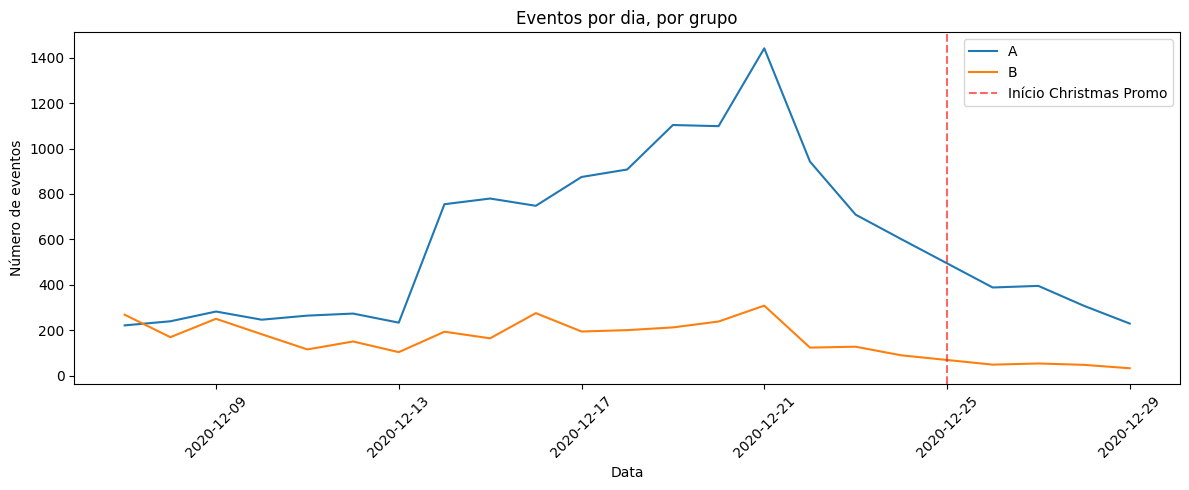

In [17]:
import matplotlib.pyplot as plt

# Criando uma coluna só com a data (sem hora) para agrupar por dia
events_teste['data'] = events_teste['event_dt'].dt.date

eventos_por_dia = events_teste.groupby(['data', 'group']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
eventos_por_dia.plot(ax=ax)
ax.set_title('Eventos por dia, por grupo')
ax.set_xlabel('Data')
ax.set_ylabel('Número de eventos')
ax.axvline(pd.Timestamp('2020-12-25'), color='red', linestyle='--', alpha=0.6, label='Início Christmas Promo')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretação: distribuição de eventos por dia

O volume de eventos cresce até ~21/12 (fim do período de cadastro) e depois
declina de forma constante, refletindo a dinâmica natural do teste (usuários
saindo da janela de 14 dias sem novos entrando). Não há evidência de que a
campanha "Christmas & New Year Promo" (iniciada em 25/12) tenha distorcido o
volume de eventos — a curva já está em declínio antes do início da campanha
e segue caindo depois, sem pico visível. O grupo B mantém volume
consistentemente menor que A ao longo de todo o período, refletindo o
desbalanceamento amostral já identificado, não uma anomalia temporal nova.

<div style="background-color:#fce4ec; padding:14px; border-left:6px solid #ad1457;">

# 🧪 Fase 3 — Teste A/B (Teste Z de Proporções)

Nesta fase, testamos estatisticamente se as diferenças de conversão
observadas na Fase 2 entre os grupos A e B são reais ou fruto de variação
amostral. Usamos o teste Z para duas proporções, com correção de Bonferroni
para múltiplas comparações, avaliando se o grupo B atingiu o aumento de
+10% esperado em cada etapa do funil.

</div>

### Teste Z para diferença de conversão entre grupos

Para cada etapa do funil, comparamos a proporção de conversão entre os
grupos A e B usando um teste Z para duas proporções — apropriado aqui porque
estamos comparando taxas (proporções binárias: converteu ou não) entre duas
amostras independentes, com tamanho suficiente para a aproximação normal.

- **H0:** a proporção de conversão é igual entre os grupos A e B.
- **H1:** a proporção de conversão é diferente entre os grupos A e B.
- Nível de significância: α = 0.05.

Como estamos testando 3 etapas do funil (3 comparações), aplicamos a
correção de Bonferroni para reduzir o risco de falso positivo por
comparações

In [18]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

alpha_ajustado = 0.05 / 3  # correção de Bonferroni para 3 comparações

def testar_conversao(sucesso_a, total_a, sucesso_b, total_b, nome_etapa):
    """Executa um teste Z de duas proporções e imprime o resultado formatado.

    Trata explicitamente o caso em que o teste retorna NaN (ex: quando o
    número de sucessos excede o total, uma situação degenerada para a
    fórmula do teste Z de proporções) — nesse caso, o resultado é reportado
    como indisponível, não como "não significativo".

    Parameters
    ----------
    sucesso_a, sucesso_b : int
        Número de usuários que atingiram a etapa, em cada grupo.
    total_a, total_b : int
        Base de cálculo (denominador) de cada grupo — o total de
        participantes do grupo, conforme o critério da especificação técnica.
    nome_etapa : str
        Nome da etapa, usado apenas para exibição do resultado.
    """
    contagem = [sucesso_b, sucesso_a]
    nobs = [total_b, total_a]

    stat, p_valor = proportions_ztest(contagem, nobs)

    print(f"--- {nome_etapa} ---")
    print(f"Conversão A: {sucesso_a}/{total_a} = {sucesso_a/total_a*100:.2f}%")
    print(f"Conversão B: {sucesso_b}/{total_b} = {sucesso_b/total_b*100:.2f}%")
    print(f"Estatística Z: {stat}")
    print(f"p-valor: {p_valor}")

    if np.isnan(p_valor):
        print("Teste inválido: resultado degenerado (NaN) — não é possível concluir.")
    elif p_valor < alpha_ajustado:
        print("Rejeitamos H0: diferença estatisticamente significativa.")
    else:
        print("Não rejeitamos H0: sem evidência de diferença significativa.")
    print()

In [19]:
# Total de participantes válidos por grupo (base fixa do funil)
total_por_grupo = participants_rec.groupby('group')['user_id'].nunique()
print(total_por_grupo)

group
A    1939
B     655
Name: user_id, dtype: int64


In [20]:
total_a = total_por_grupo['A']
total_b = total_por_grupo['B']

# Etapa 1: product_page (sobre o total do grupo)
testar_conversao(funil.loc['A', 'product_page'], total_a, funil.loc['B', 'product_page'], total_b, "product_page (% do total do grupo)")

# Etapa 2: product_cart (sobre o total do grupo)
testar_conversao(funil.loc['A', 'product_cart'], total_a, funil.loc['B', 'product_cart'], total_b, "product_cart (% do total do grupo)")

# Etapa 3: purchase (sobre o total do grupo)
testar_conversao(funil.loc['A', 'purchase'], total_a, funil.loc['B', 'purchase'], total_b, "purchase (% do total do grupo)")

--- product_page (% do total do grupo) ---
Conversão A: 1265/1939 = 65.24%
Conversão B: 367/655 = 56.03%
Estatística Z: -4.218641338913336
p-valor: 2.457788807458198e-05
Rejeitamos H0: diferença estatisticamente significativa.

--- product_cart (% do total do grupo) ---
Conversão A: 589/1939 = 30.38%
Conversão B: 184/655 = 28.09%
Estatística Z: -1.105383948907519
p-valor: 0.26899325584838074
Não rejeitamos H0: sem evidência de diferença significativa.

--- purchase (% do total do grupo) ---
Conversão A: 613/1939 = 31.61%
Conversão B: 191/655 = 29.16%
Estatística Z: -1.1740915375214591
p-valor: 0.24035836270660693
Não rejeitamos H0: sem evidência de diferença significativa.



### Nota sobre o teste product_cart → purchase (análise complementar de transição)

Este teste faz parte da análise complementar de transições entre etapas
consecutivas (quem chegou na etapa anterior → quem avançou), mantida como
informação adicional, mas que **não é o critério oficial de sucesso** da
especificação técnica (esse critério foi avaliado corretamente na seção
anterior, com a conversão de cada etapa sobre o total do grupo).

O teste Z para essa transição específica retornou `NaN`, porque a
"conversão" calculada ultrapassa 100% em ambos os grupos (A: 104,07%; B:
103,80%) — resultado da particularidade já identificada, de que existem mais
compras do que eventos de carrinho registrados. Um teste de proporção
pressupõe que sucessos não podem exceder o total de tentativas, então essa
transição não pode ser validada estatisticamente da forma como foi definida.
Interpretamos isso como mais uma limitação dos dados, não um problema com o
teste em si: o dado disponível não permite isolar corretamente essa transição
específica do funil.

**Importante:** com a correção da função `testar_conversao`, esse caso agora
é identificado explicitamente como "Teste inválido: resultado degenerado
(NaN)" — evitando o erro anterior de reportar "não rejeitamos H0" para um
teste que, na prática, não pôde ser calculado.

<div style="background-color:#fff3e0; padding:14px; border-left:6px solid #ef6c00;">

# 📝 Fase 4 — Conclusões e Recomendações

Consolidamos os achados das três fases anteriores: a validade do desenho
experimental, o comportamento observado no funil de conversão, e os
resultados dos testes estatísticos — traduzindo tudo em recomendações
práticas para o negócio.

</div>

## Conclusões

Nesse projeto eu analisei o teste A/B `recommender_system_test`, feito pela loja online pra testar um novo sistema de recomendação. A ideia era ver se o grupo B (com o sistema novo) convertia pelo menos 10% melhor que o grupo A (controle) em cada etapa do funil: visualizar produto → adicionar ao carrinho → comprar.

**Primeiro, sobre a qualidade do teste em si** — e aqui apareceram vários problemas sérios:

1. A tabela de participantes tinha dois testes A/B misturados. Depois de filtrar só o nosso teste, ainda sobrava um problema maior: 887 usuários (24% da amostra) também estavam participando do outro teste ao mesmo tempo, o que contamina os resultados. Tive que remover esses usuários.

2. Mesmo depois de limpar, os grupos ficaram bem desbalanceados: 1.939 usuários no grupo A contra só 655 no grupo B (quase 3 pra 1). Isso não é o ideal pra comparar dois grupos.

3. Encontrei 194 participantes que não eram da região esperada (UE) — a especificação pedia só usuários da UE, mas apareceu gente de N.America, APAC e CIS. Removi esses também.

4. O cronograma do teste também tinha um problema: como o cadastro de novos usuários parou em 21/12 mas o teste só terminou em 01/01, quem entrou nos últimos dias não teve os 14 dias completos prometidos pra converter. Isso afetou 31% da amostra (810 pessoas).

5. **Cobertura de novos usuários da UE:** a especificação previa 15% dos novos usuários da UE como público do teste, mas essa cobertura não foi verificada contra a base completa de cadastros — é mais uma checagem que deveria ter sido feita para validar se o teste atingiu o público planejado, e que fica registrada aqui como falha de execução ainda não fechada.

No fim, depois de todos esses filtros, sobraram só 2.594 participantes válidos (bem menos que os 6.000 esperados originalmente).

**Sobre o comportamento dos usuários:** o grupo A se mostrou mais engajado no geral desde o início (mediana de 6 eventos por usuário, contra 4 no grupo B), não só na conversão — isso é um dado importante porque ajuda a explicar o resultado do teste, e não só um detalhe à parte. Também notei que o número de compras foi maior que o número de eventos de carrinho nos dois grupos, o que sugere que nem toda compra passa pelo carrinho rastreado. Não achei evidência de que a campanha de Natal tenha distorcido os resultados — o volume de eventos já estava caindo antes dela começar, o que o gráfico por dia confirma.

**Sobre o resultado do teste A/B:** aqui é essencial usar o critério certo. A especificação define a conversão de cada etapa como a fração do total de participantes do grupo que chegou até ali — não a taxa de transição entre uma etapa e a seguinte. Medindo dessa forma:

- Na etapa `product_page`, o grupo B convertia **56,03%**, contra **65,24%** do grupo A — uma diferença de 9,21 pontos percentuais **a favor do grupo A**, estatisticamente significativa mesmo após a correção de Bonferroni (p ≈ 0,0000246). Ou seja, o grupo B chega **menos** à página do produto, não mais.
- Nas etapas `product_cart` (30,38% vs 28,09%) e `purchase` (31,61% vs 29,16%), não há diferença estatisticamente significativa entre os grupos.

Essa diferença no topo do funil provavelmente não é efeito do sistema de recomendação — é reflexo do desbalanceamento e da diferença de engajamento que os dois grupos já tinham desde o início (o grupo A, mais numeroso e mais engajado, naturalmente concentra mais gente chegando à página do produto). Também testei uma leitura alternativa, olhando as transições entre etapas consecutivas (de quem chegou na etapa anterior, quantos avançaram) — nessa leitura, o grupo B parecia converter melhor, mas essa é uma comparação enviesada: como menos gente do grupo B chega ao `product_page`, quem chega é um subconjunto mais seletivo, que naturalmente avança melhor daí pra frente. Esse viés de seleção não deve ser confundido com o critério oficial da especificação.

**Em nenhuma das três etapas a meta de +10% de aumento foi atingida.** Pelo contrário: na etapa mais importante do funil (a entrada), o resultado foi significativamente pior no grupo B.

**Minhas recomendações:**

1. **Não recomendo lançar o novo sistema de recomendação com base nesse teste.** Não há evidência de melhora em nenhuma etapa, e o resultado no topo do funil é oposto ao esperado — mas essa diferença não pode ser atribuída ao sistema, já que os grupos já divergiam em engajamento antes de qualquer efeito do tratamento.

2. **O teste precisa ser refeito com um desenho melhor**: sem sobreposição com outros testes, com grupos balanceados (50/50) e comparáveis em engajamento inicial, respeitando o público-alvo definido (só UE, cobrindo os 15% previstos) e com um cronograma que garanta os 14 dias completos pra todo mundo.

3. **Vale revisar o tracking do evento de carrinho**, já que ele está com menos registros que o de compra — isso indica que a empresa pode estar perdendo dados importantes do meio do funil, o que atrapalha qualquer análise futura desse tipo.

No fim, o processo valeu a pena mesmo sem confirmar que o sistema novo funciona: descobri vários problemas reais no desenho do experimento — incluindo um erro que eu mesmo cometi na primeira leitura dos resultados (usar a base de cálculo errada no funil) — que, se não forem corrigidos, vão continuar prejudicando testes futuros da empresa.

### Diagnóstico da tabela de eventos de marketing

Última tabela ainda sem diagnóstico formal. Verificamos tipos, nulos e
duplicados, e aproveitamos para confirmar quais campanhas se sobrepõem ao
período do nosso teste (07/12/2020 a 01/01/2021) e à região UE.

In [21]:
# Checando tipos, nulos e duplicados na tabela de marketing
print(marketing.dtypes)
print()
print("Nulos por coluna:")
print(marketing.isnull().sum())
print()
print("Linhas duplicadas:", marketing.duplicated().sum())


name         object
regions      object
start_dt     object
finish_dt    object
dtype: object

Nulos por coluna:
name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

Linhas duplicadas: 0


### Convertendo datas e identificando campanhas sobrepostas ao teste

Convertemos start_dt e finish_dt para datetime, e filtramos quais campanhas
se sobrepõem ao período do nosso teste (07/12/2020 a 01/01/2021) e incluem
a região UE — candidatas a interferir nos resultados.

In [22]:
# Convertendo as datas de início e fim das campanhas
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

# Período do nosso teste
inicio_teste = pd.Timestamp('2020-12-07')
fim_teste = pd.Timestamp('2021-01-01')

# Campanhas que se sobrepõem ao período do teste E incluem a região EU
sobrepostas = marketing[
    (marketing['start_dt'] <= fim_teste) &
    (marketing['finish_dt'] >= inicio_teste) &
    (marketing['regions'].str.contains('EU'))
]

print(sobrepostas)

                       name        regions   start_dt  finish_dt
0  Christmas&New Year Promo  EU, N.America 2020-12-25 2021-01-03


### Confirmação: apenas 1 campanha se sobrepõe ao teste

Apenas a campanha "Christmas & New Year Promo" (25/12/2020 a 03/01/2021,
regiões EU e N.America) se sobrepõe ao período do `recommender_system_test`
na região UE. Como já observamos na análise de eventos por dia, essa
sobreposição não parece ter distorcido os resultados — o volume de eventos
já estava em declínio antes do início da campanha. Ainda assim, é uma
limitação a se ter em mente: qualquer efeito residual da campanha (por
exemplo, em usuários com maior tempo de exposição a ela) não pode ser
completamente descartado apenas por essa inspeção.

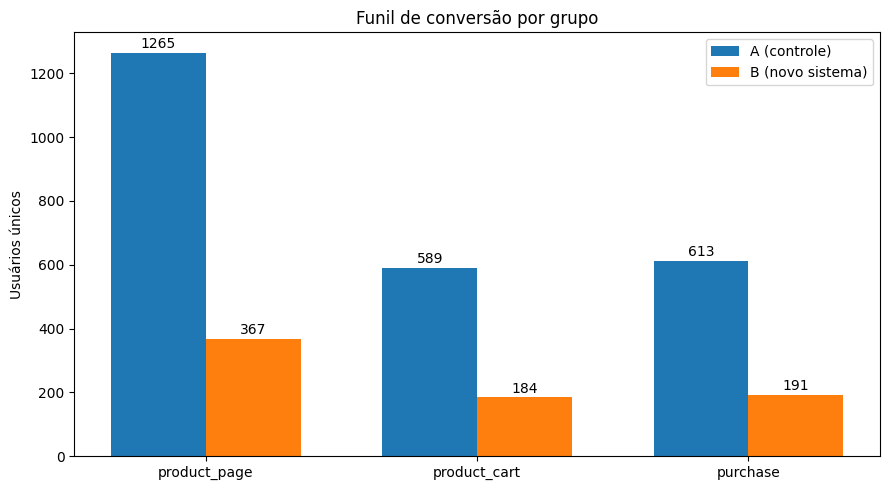

In [23]:
import matplotlib.pyplot as plt

etapas = ['product_page', 'product_cart', 'purchase']
valores_a = funil.loc['A', etapas]
valores_b = funil.loc['B', etapas]

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(etapas))
largura = 0.35

ax.bar([i - largura/2 for i in x], valores_a, largura, label='A (controle)')
ax.bar([i + largura/2 for i in x], valores_b, largura, label='B (novo sistema)')

ax.set_xticks(x)
ax.set_xticklabels(etapas)
ax.set_ylabel('Usuários únicos')
ax.set_title('Funil de conversão por grupo')
ax.legend()

# Adicionando os rótulos de valor em cada barra
for i, (va, vb) in enumerate(zip(valores_a, valores_b)):
    ax.text(i - largura/2, va + 15, str(va), ha='center')
    ax.text(i + largura/2, vb + 15, str(vb), ha='center')

plt.tight_layout()
plt.show()

### Interpretação do funil visual

Em volume absoluto, o grupo A tem mais usuários em todas as etapas — mas
isso é consequência direta do desbalanceamento amostral (A tem quase 3x mais
participantes que B), não um indicativo de melhor desempenho. A comparação
relevante é a **taxa de conversão** entre etapas (calculada anteriormente),
que mostrou o grupo B numericamente à frente, embora sem significância
estatística.

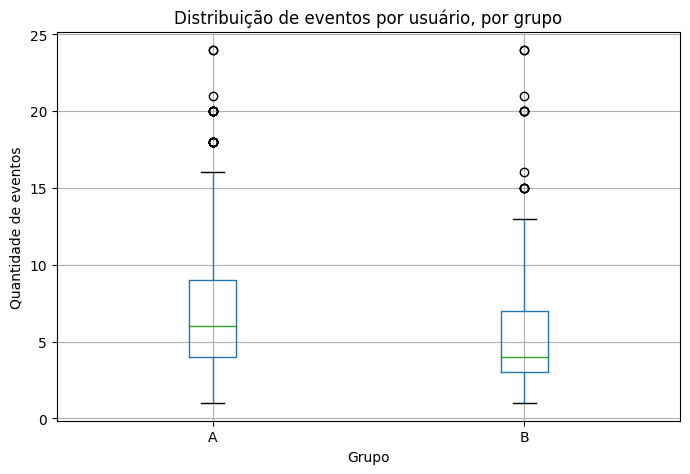

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))

eventos_por_usuario.boxplot(column='qtd_eventos', by='group', ax=ax)
ax.set_title('Distribuição de eventos por usuário, por grupo')
ax.set_xlabel('Grupo')
ax.set_ylabel('Quantidade de eventos')
plt.suptitle('')

plt.tight_layout()
plt.show()

### Interpretação: distribuição de eventos por usuário

O boxplot confirma visualmente o achado anterior: a mediana de eventos por
usuário no grupo A (6) é claramente maior que no grupo B (4), com toda a
distribuição do grupo A deslocada para cima. Isso reforça que os dois grupos
não são apenas diferentes em tamanho, mas também em padrão de engajamento —
mais um fator que compromete a comparabilidade direta entre eles.